In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kartik2112_fraud_detection_path = kagglehub.dataset_download('kartik2112/fraud-detection')

print('Data source import complete.')

Using Colab cache for faster access to the 'fraud-detection' dataset.
Data source import complete.


**CREDIT CARD FRAUD DETECTION:**
   
The problem focuses on analyzing a financial transaction dataset to identify and understand fraudulent activities. The objective is to explore the data, detect patterns, and perform data cleaning and preprocessing to support effective analysis and visualization, helping in understanding trends and improving decision-making related to fraud detection.

In [ ]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,RobustScaler,LabelEncoder,MinMaxScaler
from scipy.stats import zscore,skew
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

**WEEK 02 – KNOW YOUR DATA**

This step focuses on understanding the dataset by exploring its structure, features, and overall quality. The code loads the dataset and displays the first and last few rows to get an initial view of the data. It then examines column names, dataset shape, and data types to understand how the data is organized. Statistical summaries are generated to analyze numerical features, and missing values are checked to identify any data cleaning requirements.

This step is important because it helps identify data issues such as missing values, incorrect data types, or inconsistencies early in the process. Understanding the dataset ensures better preprocessing, improves model performance, and reduces errors in later stages of analysis.

In [ ]:
#WEEK 02 – KNOW YOUR DATA
print("Week : 02 ")

#LOADING THE DATASET
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")

#PRINTING FIRST FIVE ROWS
print("\nFirst Five Rows:\n")
print(df.head())

#PRINTING LAST FIVE ROWS
print("\nLast Five Rows:\n")
print(df.tail())

#CHECKING THE DATA STRUCTURE
print("\nColumn Names:\n")
print(df.columns)
print("\nNumber of Rows and Columns:\n")
print(df.shape)

#CHECKING DATA TYPES
print("\nDataset Information:\n")
print(df.info())
print("\nData Types of Each Column:\n")
print(df.dtypes)

#STATISTICAL SUMMARY
print("\nStatistical Summary:\n")
print(df.describe())

#CHECKING FOR MISSING VALUES
print("\nMissing Values in Each Column:\n")
print(df.isnull().sum())

Week : 02 

First Five Rows:

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 R

**INTERPRETATION :**

The dataset contains 1,296,675 rows and 23 columns related to credit card transactions. It includes numerical and categorical features such as transaction amount, merchant details, customer information, and location data. The analysis shows that there are no missing values in the dataset. The target variable is_fraud indicates that fraudulent transactions are very few compared to legitimate ones, showing that the dataset is highly imbalanced. This dataset is suitable for further preprocessing and analysis.

**WEEK 03 – THE CLEANING SPRINT**

This stage focuses on improving data quality by handling missing values, detecting outliers, and scaling numerical features. These steps ensure that the dataset becomes clean, consistent, and suitable for accurate data analysis and visualization.

**Introducing Missing Values:**

Missing values are artificially introduced into selected columns to simulate real-world datasets where incomplete data is common. This allows effective practice of data cleaning techniques.

In [ ]:
print("Week - 03")
#THE CLEANING SPRINT

#INTRODUCING MISSING VALUES IN THE DATASET AS THE DATASET HAS NO MISSING VALUES
np.random.seed(42)
df.loc[np.random.choice(df.index, 2000, replace=False), 'amt'] = np.nan
df.loc[np.random.choice(df.index, 1500, replace=False), 'city_pop'] = np.nan
df.loc[np.random.choice(df.index, 1000, replace=False), 'merchant'] = np.nan
df.loc[np.random.choice(df.index, 1000, replace=False), 'job'] = np.nan

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print("Dataset Shape:", df.shape)

Week - 03
Dataset Shape: (1296675, 22)


**Checking Missing Values**

The following code identifies the number of missing values present in each column of the dataset.

In [ ]:
missing_counts = df.isnull().sum()

print("\nMissing Values Before Imputation:\n")
print(missing_counts)


Missing Values Before Imputation:

trans_date_trans_time       0
cc_num                      0
merchant                 1000
category                    0
amt                      2000
first                       0
last                        0
gender                      0
street                      0
city                        0
state                       0
zip                         0
lat                         0
long                        0
city_pop                 1500
job                      1000
dob                         0
trans_num                   0
unix_time                   0
merch_lat                   0
merch_long                  0
is_fraud                    0
dtype: int64


**Visualizing Missing Values:**

Visualization helps in understanding the distribution and impact of missing values across different features.

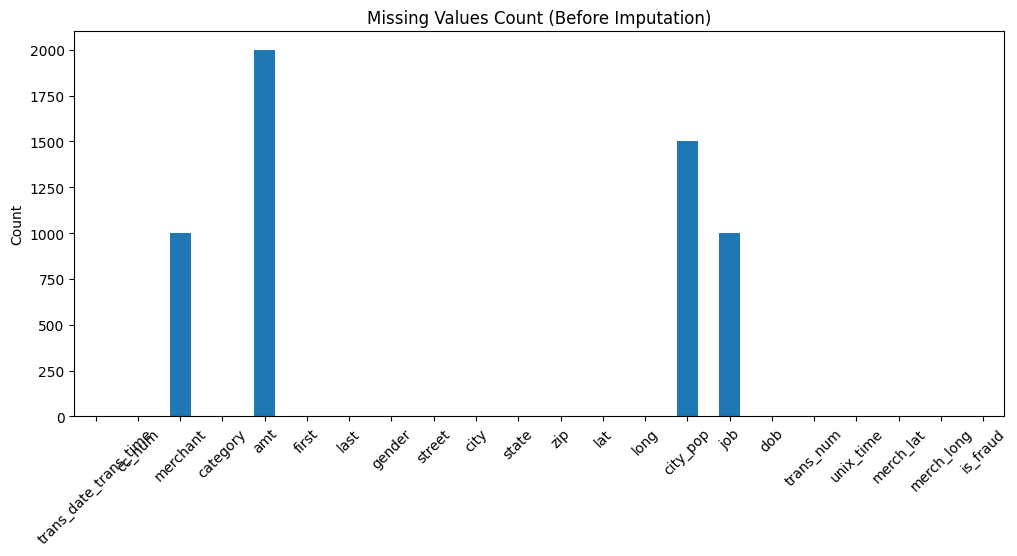

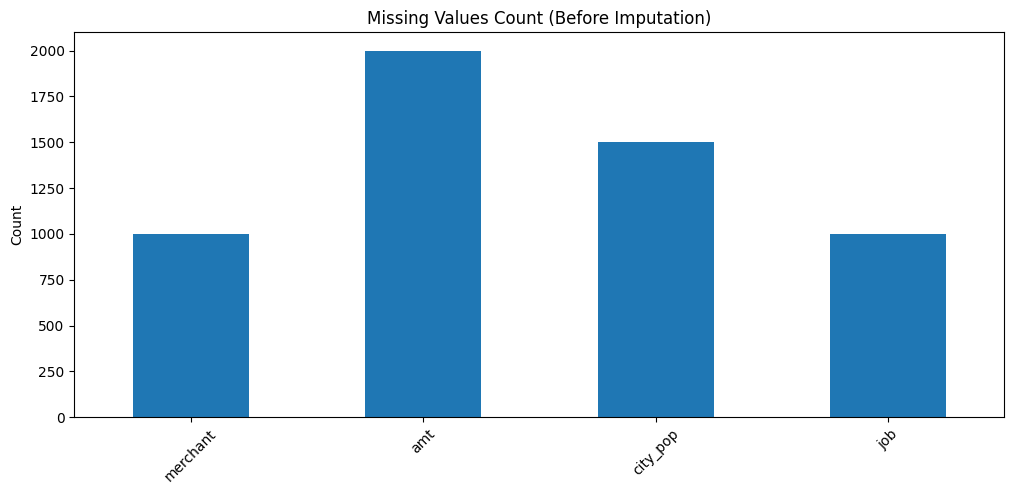

In [ ]:
#MISSING VALUES BEFORE IMPUTATION (BAR CHART)
if missing_counts.sum() > 0:
    plt.figure(figsize=(12,5))
    missing_counts.plot(kind='bar')
    plt.title("Missing Values Count (Before Imputation)")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

if missing_counts.sum() > 0:
    plt.figure(figsize=(12,5))
    missing_counts[missing_counts >0].plot(kind='bar')
    plt.title("Missing Values Count (Before Imputation)")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

**Handling Missing Values:**

Missing values in numerical columns are replaced using the median to reduce the effect of extreme values. Categorical columns are filled using the most frequent value.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

#HANDLING MISSING VALUES FOR NUMERICAL COLUMNS USING MEDIAN IMPUTATION
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

#HANDLING MISSING VALUES FOR CATEGORICAL COLUMNS USING MODE IMPUTATION
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].value_counts().idxmax())

print("\nMissing Values After Imputation:",df.isnull().sum().sum())
missing_counts1 = df.isnull().sum().sum()
print(df.isnull().sum())


Missing Values After Imputation: 0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


**Outlier Detection using IQR Method:**

The IQR method is used to identify extreme values in the transaction amount, which may affect analysis results.


Outlier Detection using IQR
Lower Bound: -100.415
Upper Bound: 193.145
Number of Outliers: 67386


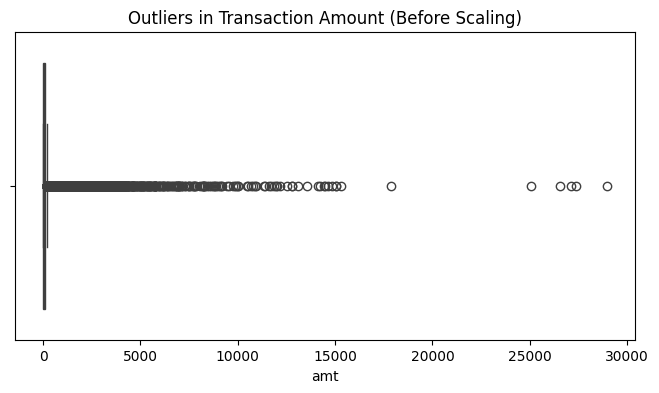

In [ ]:
#OUTLIER DETECTION USING IQR METHOD
if 'amt' in df.columns:
    Q1 = df['amt'].quantile(0.25)
    Q3 = df['amt'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df['amt'] < lower) | (df['amt'] > upper)]
    print("\nOutlier Detection using IQR")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", outliers.shape[0])


    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['amt'])
    plt.title("Outliers in Transaction Amount (Before Scaling)")
    plt.show()

**Outlier Detection using Z-Score:**

The Z-score method identifies values that significantly deviate from the mean.


Outlier Detection using Z-Score Method
Z-score Threshold: 3
Number of Outliers (Z-score): 12731


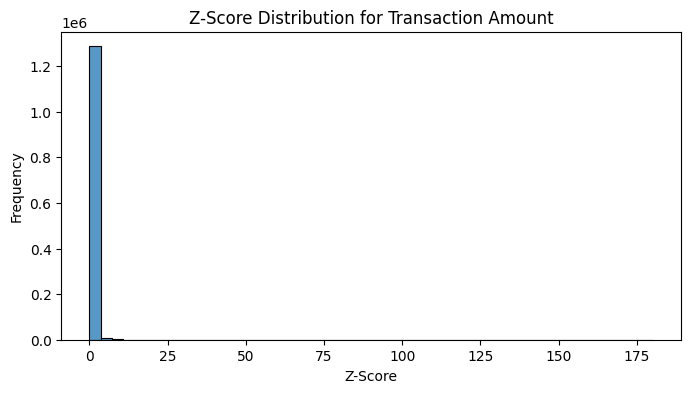

In [ ]:
#OUTLIER DETECTION USING Z-SCORE METHOD
if 'amt' in df.columns:
    z_scores = np.abs(zscore(df['amt']))
    # Threshold = 3
    outliers_zscore = df[z_scores > 3]
    print("\nOutlier Detection using Z-Score Method")
    print("Z-score Threshold: 3")
    print("Number of Outliers (Z-score):", outliers_zscore.shape[0])

    #VISUALIZATION FOR Z-SCORE
    plt.figure(figsize=(8,4))
    sns.histplot(z_scores, bins=50)
    plt.title("Z-Score Distribution for Transaction Amount")
    plt.xlabel("Z-Score")
    plt.ylabel("Frequency")
    plt.show()

**Scaling the Data:**

RobustScaler is applied to normalize the transaction amount while reducing the influence of outliers, making the data more suitable for analysis and visualization.

In [ ]:
#SCALING USING ROBUST SCALAR
if 'amt' in df.columns:
    scaler = RobustScaler()
    df['amt_scaled'] = scaler.fit_transform(df[['amt']])

**Comparing Before and After Scaling:**

This visualization shows how scaling changes the distribution of the data.

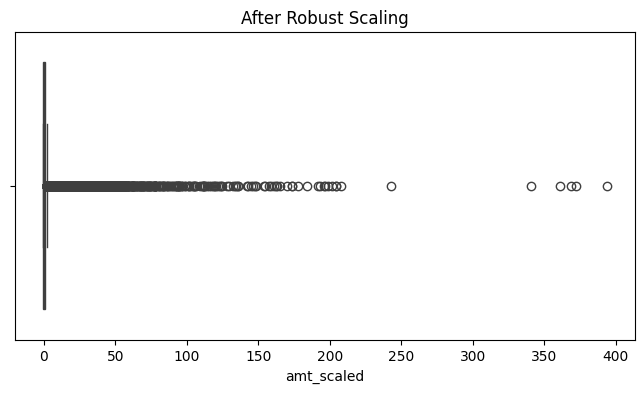

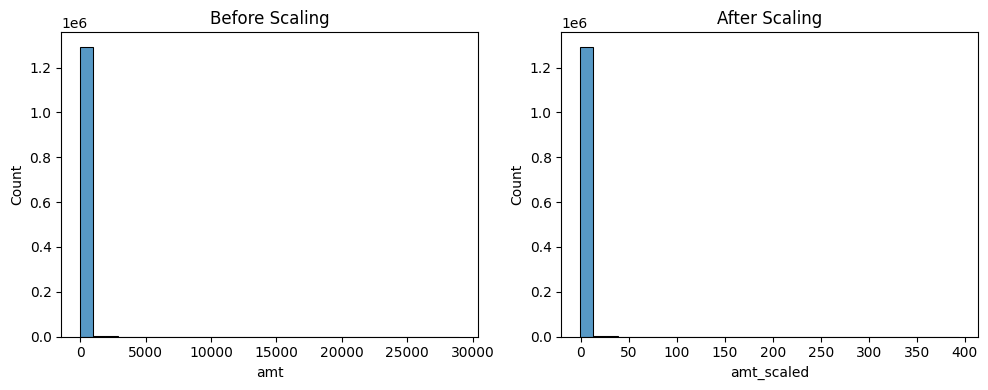

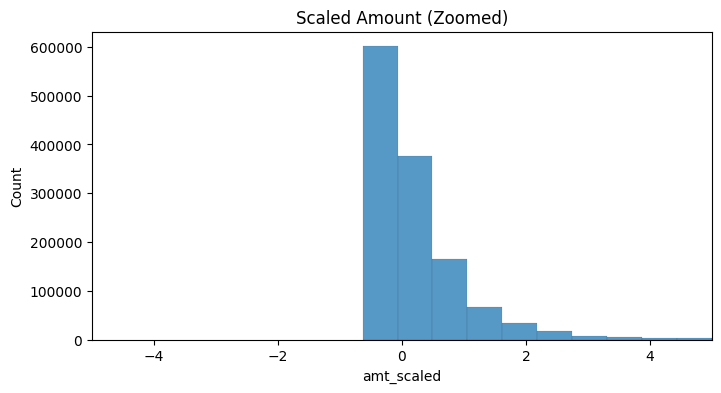

In [ ]:
 # AFTER SCALING
plt.figure(figsize=(8,4))
sns.boxplot(x=df['amt_scaled'])
plt.title("After Robust Scaling")
plt.show()

# DISTRIBUTION COMPARISON
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['amt'], bins=30)
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.histplot(df['amt_scaled'], bins=30)
plt.title("After Scaling")

plt.tight_layout()
plt.show()

for col in cat_cols:
    df[col] = df[col].astype('category')
import gc
gc.collect()

#HISTOGRAM
plt.figure(figsize=(8,4))
sns.histplot(df['amt_scaled'], bins=700)
plt.xlim(-5, 5)
plt.title("Scaled Amount (Zoomed)")
plt.show()

**THE CLEANING SPRINT - INTERPRETATION**
   
   In this stage, the dataset was analyzed to identify missing values and outliers. The dataset contains 1,296,675 rows and 22 columns after removing unnecessary attributes.

The missing value analysis shows that a few columns contained null values, specifically merchant (1000), amt (2000), city_pop (1500), and job (1000). These missing values were handled through imputation techniques, after which all columns had zero missing values, ensuring the dataset became complete for further analysis.

Outlier detection was performed on the transaction amount (amt) using the IQR method and Z-score method. The boxplot indicates that several extreme transaction values exist, which appear as outliers. To reduce the impact of these extreme values on machine learning models, Robust Scaling was applied.

After scaling, the distribution of the transaction amount became more balanced and less affected by extreme values. This preprocessing step improves the stability of the data and prepares it for exploratory data analysis.

**WEEK 04 – EXPLORATORY DATA ANALYSIS (EDA):**

This stage focuses on exploring the dataset in depth using various visualizations and statistical techniques. The aim is to understand patterns, relationships, and trends in the data, especially related to fraudulent transactions. This analysis helps in gaining meaningful insights and supports effective data interpretation.

**Setting Visualization Style & Feature Engineering:**

Visualization styles are configured for better readability. A new feature (hour) is extracted from the transaction timestamp to analyze time-based patterns in transactions.

In [ ]:
print("Week - 04")
# EXPLORATORY DATA ANALYSIS (EDA) – DEEP DIVE

sns.set_style("whitegrid")
sns.set_context("talk")

# Feature Engineering
# Extract hour from transaction timestamp
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour

# Sample data for faster visualization
df_sample = df.sample(50000, random_state=42)

Week - 04


**Univariate Analysis:**

Univariate analysis focuses on understanding the distribution of individual features such as transaction amount and transaction time.


================ UNIVARIATE ANALYSIS ================



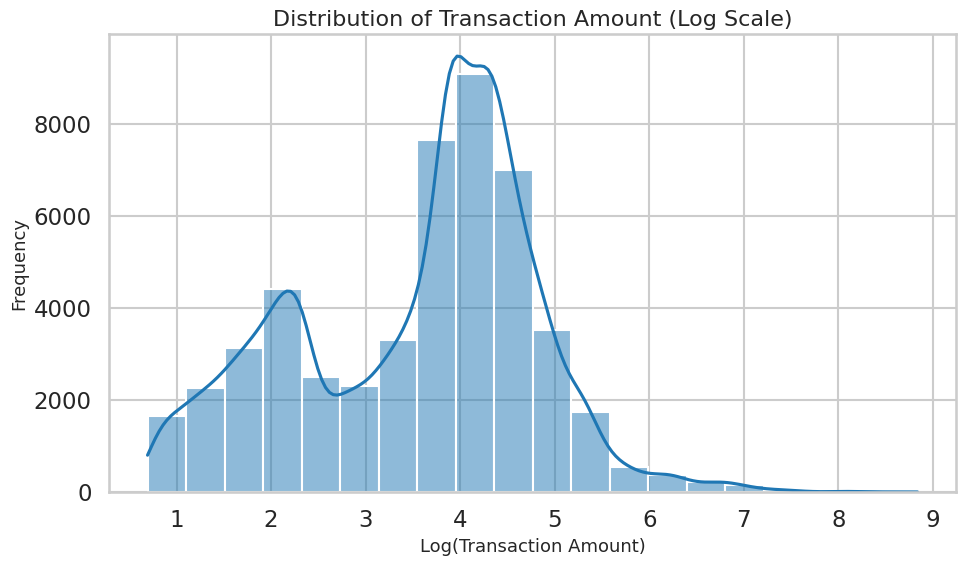

In [ ]:
print("\n================ UNIVARIATE ANALYSIS ================\n")

# Distribution of Transaction Amount (Log Scale)
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df_sample['amt']),
             bins=20,
             kde=True,
             color="#1f77b4")
plt.title("Distribution of Transaction Amount (Log Scale)", fontsize=16)
plt.xlabel("Log(Transaction Amount)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

This graph shows how the transaction amounts are distributed after applying a log transformation. Most of the values are concentrated between 3 and 5, which means the majority of transactions are of medium size. There are fewer transactions at higher values, forming a right-skewed tail. This happens because real-world financial data usually contains some very large transactions, and the log scale helps to reduce skewness and make the data easier to understand.

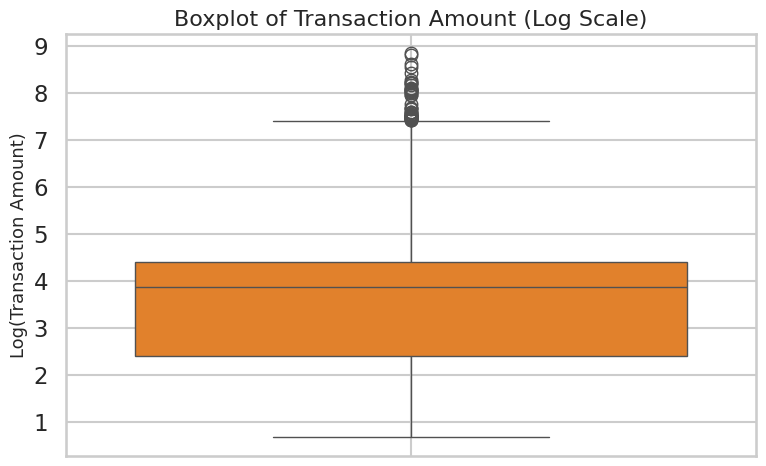

In [ ]:
# Boxplot of Transaction Amount
plt.figure(figsize=(8,5))
sns.boxplot(y=np.log1p(df_sample['amt']),
            color="#ff7f0e")
plt.title("Boxplot of Transaction Amount (Log Scale)", fontsize=16)
plt.ylabel("Log(Transaction Amount)", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

The boxplot summarizes the spread of transaction amounts. The median is around 4, and most of the data lies between 2.5 and 4.5. There are several points above the upper range, which are outliers. This indicates that while most transactions are moderate, there are some unusually large transactions. The log scale helps in clearly visualizing these variations.

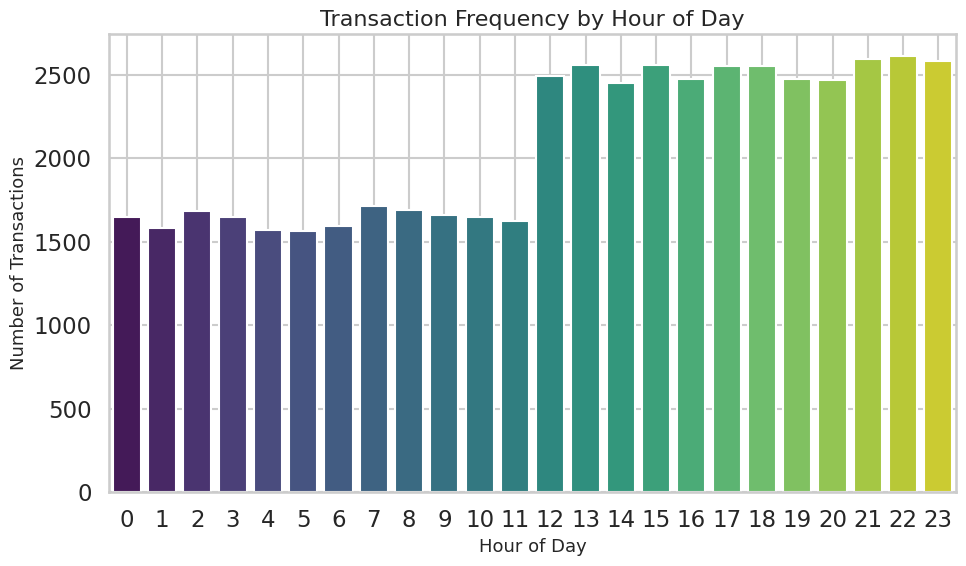

In [ ]:
# Transaction Frequency by Hour
plt.figure(figsize=(10,6))
sns.countplot(x='hour',
              data=df_sample,
              palette="viridis")
plt.title("Transaction Frequency by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Number of Transactions", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

This bar chart shows how transactions are distributed across different hours of the day. The number of transactions is lower during early hours and gradually increases during the day, peaking in the afternoon and evening. This suggests that users are more active during daytime, which is why more transactions occur during those hours.

**City Population Distribution:**

The distribution of city population is visualized using a histogram with log transformation. Since population values can vary widely, applying a log scale helps in reducing skewness and makes the distribution easier to interpret. This allows better observation of how most transactions are concentrated across different population ranges.

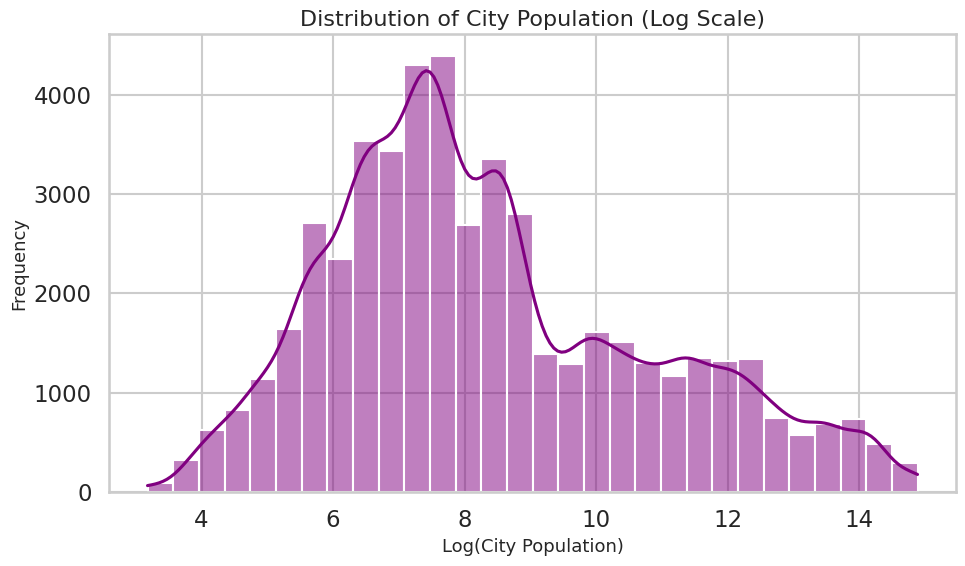

In [ ]:
#City Population Distribution
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df_sample['city_pop']),
             bins=30,
             kde=True,
             color="purple")
plt.title("Distribution of City Population (Log Scale)", fontsize=16)
plt.xlabel("Log(City Population)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.tight_layout()
plt.show()

**Transaction Category Percentage:**

This visualization shows the percentage distribution of different transaction categories. Instead of raw counts, percentages provide a better understanding of the relative importance of each category. It helps identify which types of transactions occur most frequently in the dataset.

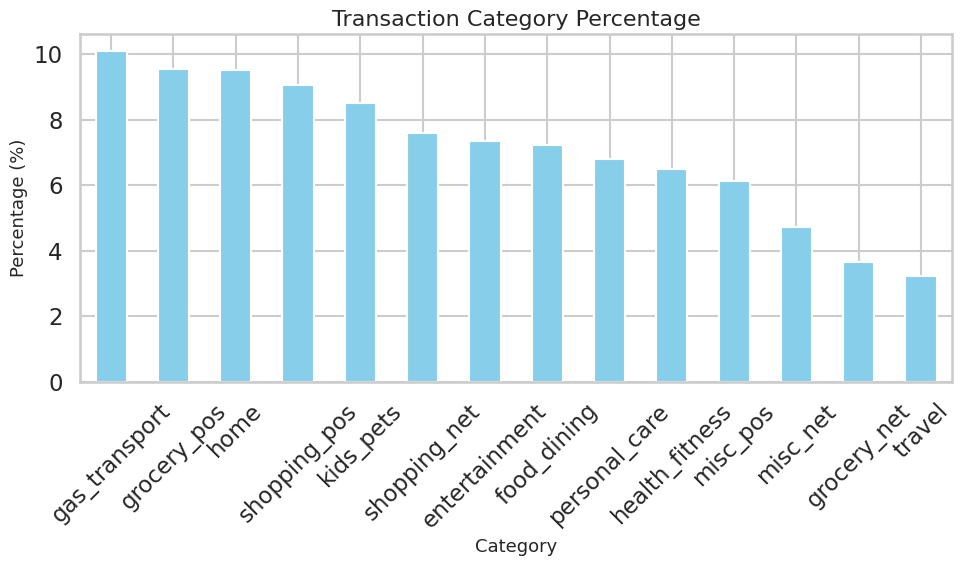

In [ ]:
#Transaction Category Percentage
category_percent = df_sample['category'].value_counts(normalize=True)*100
plt.figure(figsize=(10,6))
category_percent.plot(kind='bar', color="skyblue")
plt.title("Transaction Category Percentage", fontsize=16)
plt.xlabel("Category", fontsize=13)
plt.ylabel("Percentage (%)", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Gender Distribution:**

The gender distribution plot shows the count of transactions made by different genders. This helps in understanding whether the dataset is balanced across gender categories. It also provides insight into user demographics present in the data.

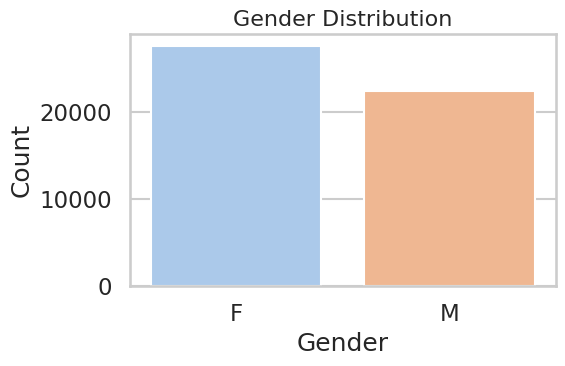

In [ ]:
#Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df_sample, palette="pastel")
plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Bivariate Analysis:**

Bivariate analysis examines the relationship between two variables, especially focusing on fraud vs non-fraud behavior.


================ BIVARIATE ANALYSIS ================



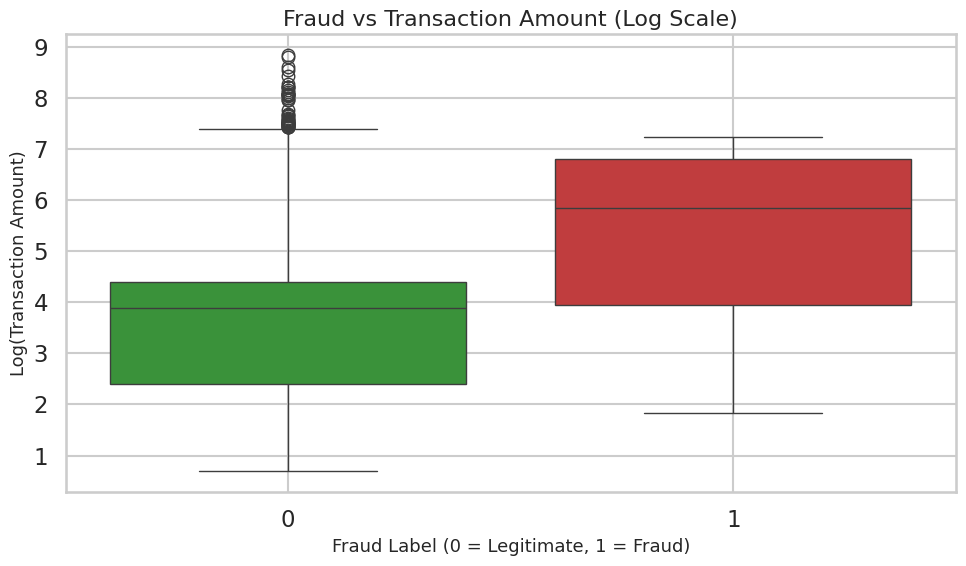

In [ ]:
print("\n================ BIVARIATE ANALYSIS ================\n")

# Fraud vs Transaction Amount
plt.figure(figsize=(10,6))
sns.boxplot(x='is_fraud',
            y=np.log1p(df_sample['amt']),
            data=df_sample,
            palette=["#2ca02c", "#d62728"])
plt.title("Fraud vs Transaction Amount (Log Scale)", fontsize=16)
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraud)", fontsize=13)
plt.ylabel("Log(Transaction Amount)", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

This visualization compares transaction amounts for fraud and non-fraud cases. It is clear that fraud transactions generally have higher values compared to normal transactions. The median for fraud is higher, indicating that fraudulent activities are often associated with larger transaction amounts.

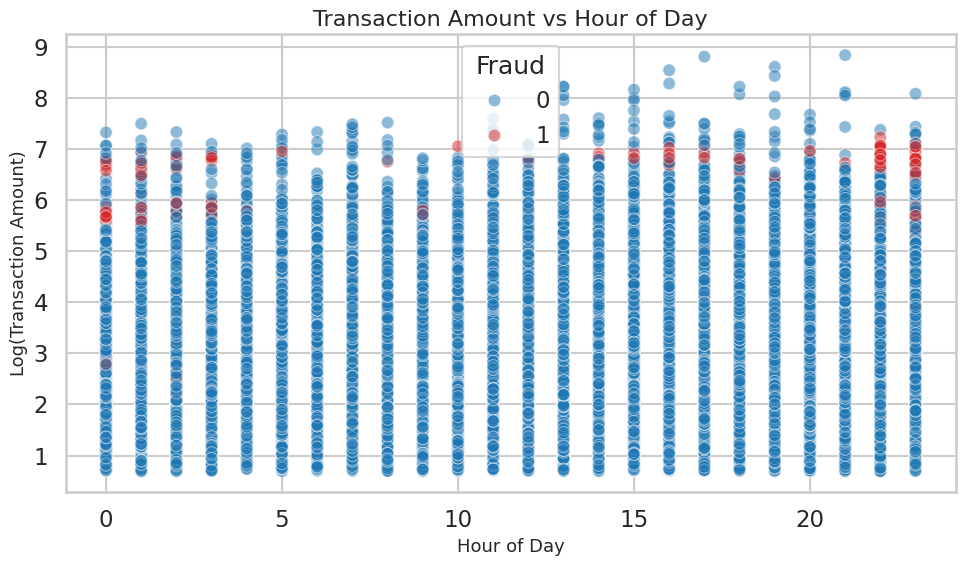

In [ ]:
#Transaction Amount vs Hour
plt.figure(figsize=(10,6))
sns.scatterplot(x='hour',
                y=np.log1p(df_sample['amt']),
                hue='is_fraud',
                data=df_sample,
                alpha=0.5,
                palette={0:"#1f77b4",1:"#d62728"})
plt.title("Transaction Amount vs Hour of Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Log(Transaction Amount)", fontsize=13)
plt.legend(title="Fraud")
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

This scatter plot shows transaction amounts at different hours, with fraud cases highlighted. The data points are spread across all hours, showing that transactions happen throughout the day. Fraud cases are scattered and do not follow a strict time pattern, but they are slightly more visible at higher transaction values. This suggests that fraud is not time-dependent but is more related to transaction size.

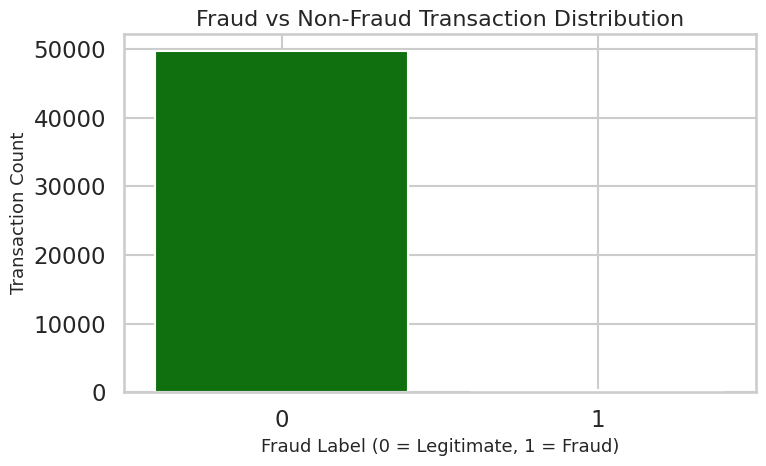

In [ ]:
# Fraud vs Non-Fraud Transactions
plt.figure(figsize=(8,5))
sns.countplot(x='is_fraud',
              data=df_sample,
              palette=["green","red"])
plt.title("Fraud vs Non-Fraud Transaction Distribution", fontsize=16)
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraud)", fontsize=13)
plt.ylabel("Transaction Count", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

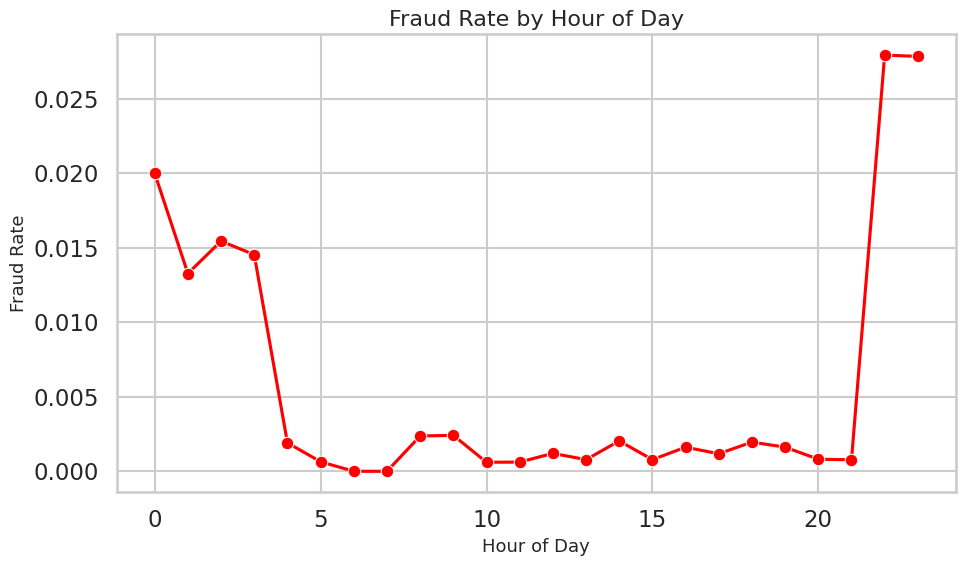

In [ ]:
# Fraud Rate by Hour
fraud_hour = df_sample.groupby('hour')['is_fraud'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x='hour',
             y='is_fraud',
             data=fraud_hour,
             marker='o',
             color="red")
plt.title("Fraud Rate by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Fraud Rate", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

**Category vs Fraud:**

This plot shows how fraud is distributed across different transaction categories. By comparing fraud and non-fraud counts within each category, it becomes easier to identify which categories are more prone to fraudulent activities. Categories with relatively higher fraud counts may require closer attention.

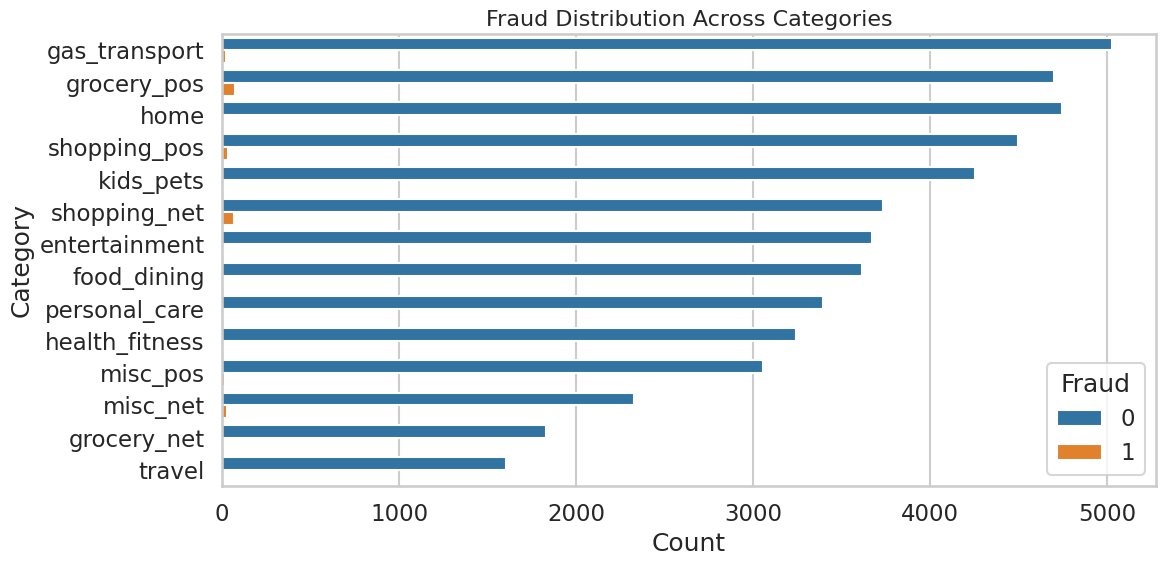

In [ ]:
#Category vs Fraud
plt.figure(figsize=(12,6))
sns.countplot(y='category',
              hue='is_fraud',
              data=df_sample,
              order=df_sample['category'].value_counts().index)
plt.title("Fraud Distribution Across Categories", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Category")
plt.legend(title="Fraud")
plt.tight_layout()
plt.show()

**City Population vs Fraud:**

This boxplot compares city population distributions between fraudulent and non-fraudulent transactions. The use of log transformation helps in handling large variations in population values. This visualization helps determine whether fraud is more common in cities with certain population ranges.

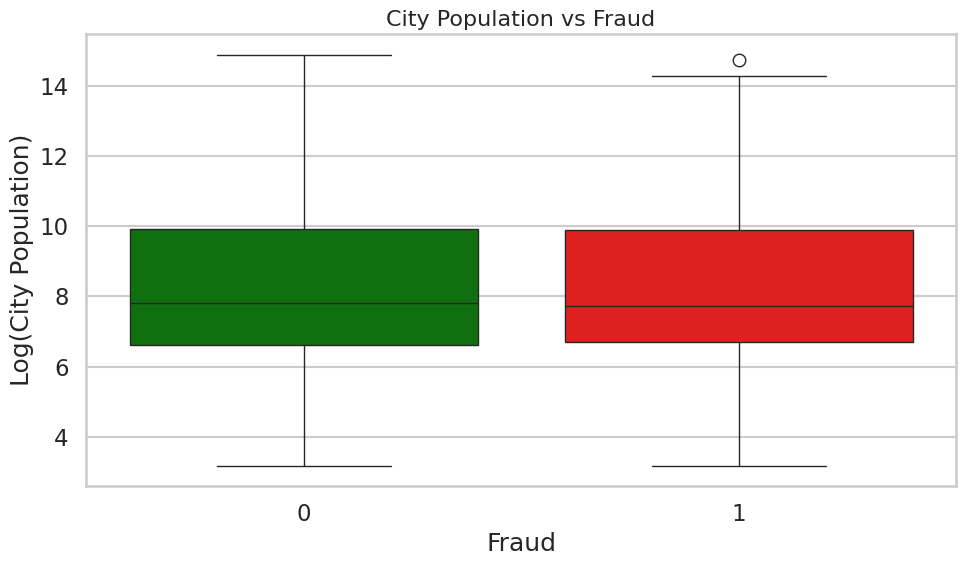

In [ ]:
#City Population vs Fraud
plt.figure(figsize=(10,6))
sns.boxplot(x='is_fraud',
            y=np.log1p(df_sample['city_pop']),
            data=df_sample,
            palette=["green","red"])
plt.title("City Population vs Fraud", fontsize=16)
plt.xlabel("Fraud")
plt.ylabel("Log(City Population)")
plt.tight_layout()
plt.show()

**Transaction Amount vs Category:**

This plot shows how transaction amounts vary across different categories. Log transformation is applied to make the distribution clearer and reduce skewness. It helps in identifying which categories tend to have higher or lower transaction amounts.

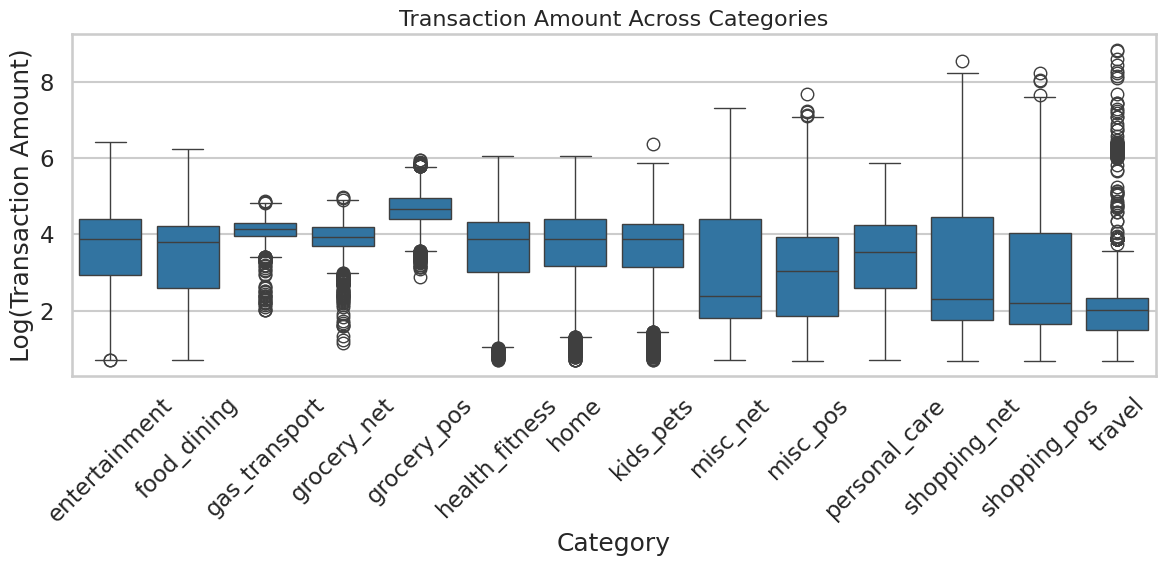

In [ ]:
#Transaction Amount vs Category
plt.figure(figsize=(12,6))
sns.boxplot(x='category',
            y=np.log1p(df_sample['amt']),
            data=df_sample)
plt.title("Transaction Amount Across Categories", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Log(Transaction Amount)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Fraud Rate by Hour and Category:**

This heatmap shows the average fraud rate across different hours and transaction categories. It combines time and category information to highlight patterns in fraud occurrence. Darker regions indicate higher fraud rates, making it easy to spot critical time-category combinations.

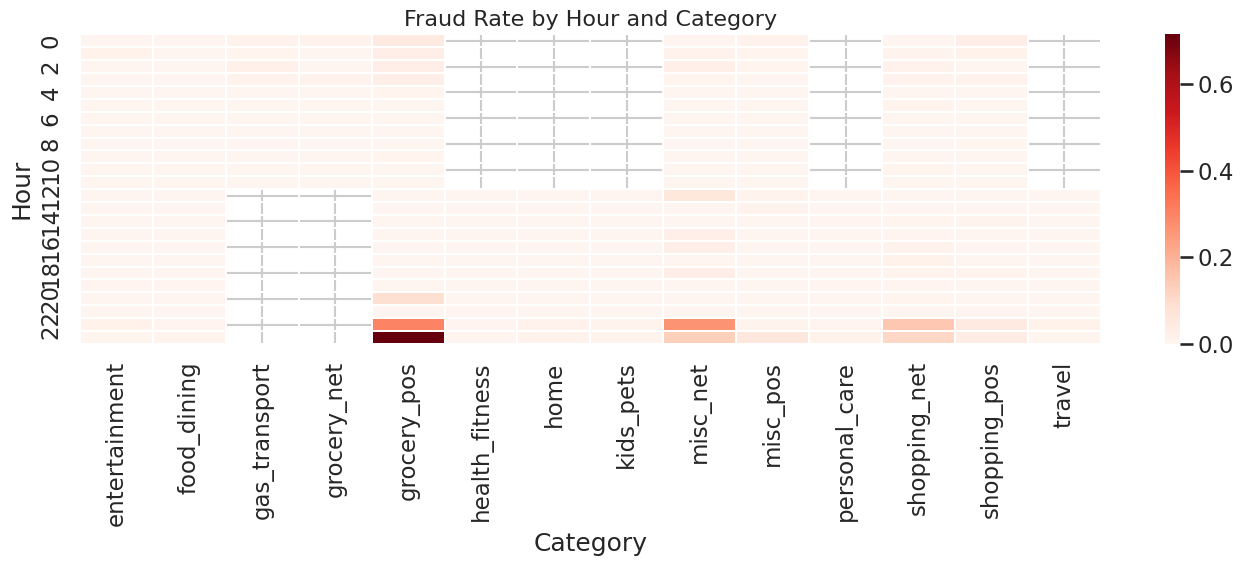

In [ ]:
#Heatmap of Fraud by Hour and Category
pivot_table = pd.pivot_table(df_sample,
                             values='is_fraud',
                             index='hour',
                             columns='category',
                             aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table,
            cmap='Reds',
            linewidths=0.2)
plt.title("Fraud Rate by Hour and Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

**Multivariate Analysis:**

Multivariate analysis helps understand relationships among multiple variables simultaneously.


================ MULTIVARIATE ANALYSIS ================



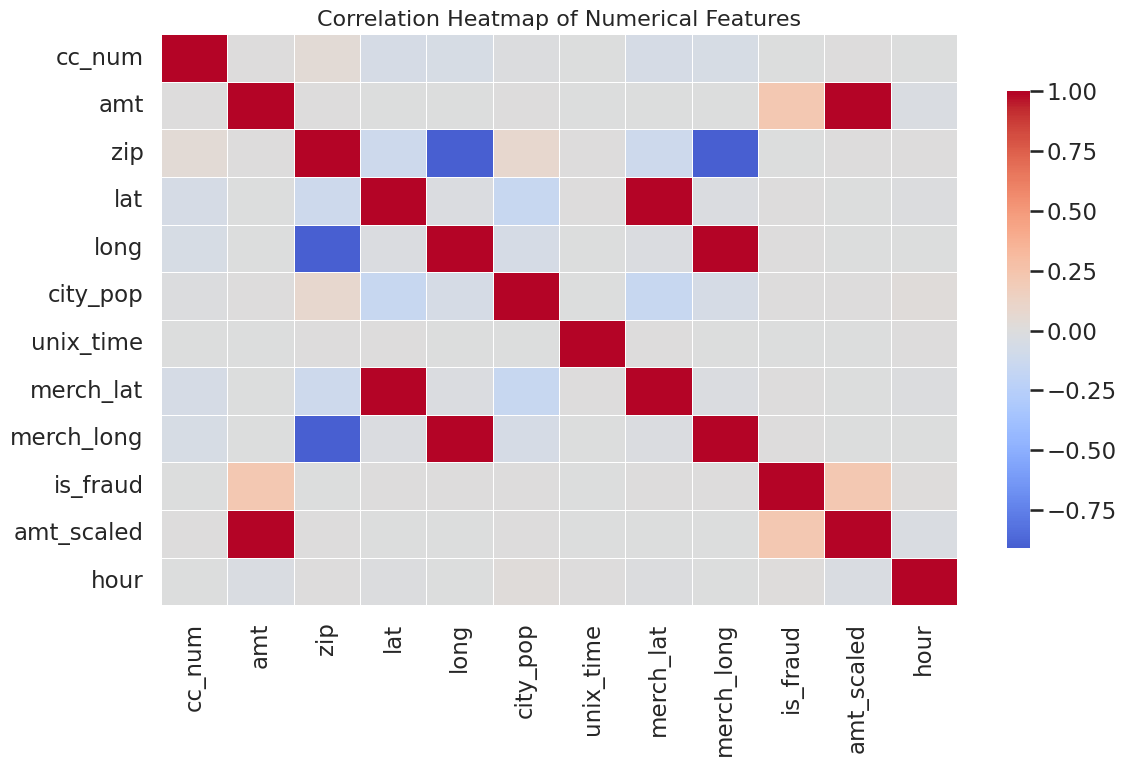

In [ ]:
print("\n================ MULTIVARIATE ANALYSIS ================\n")

# Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            linewidths=0.5,
            center=0,
            cbar_kws={"shrink":0.8})
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()
print("\n")

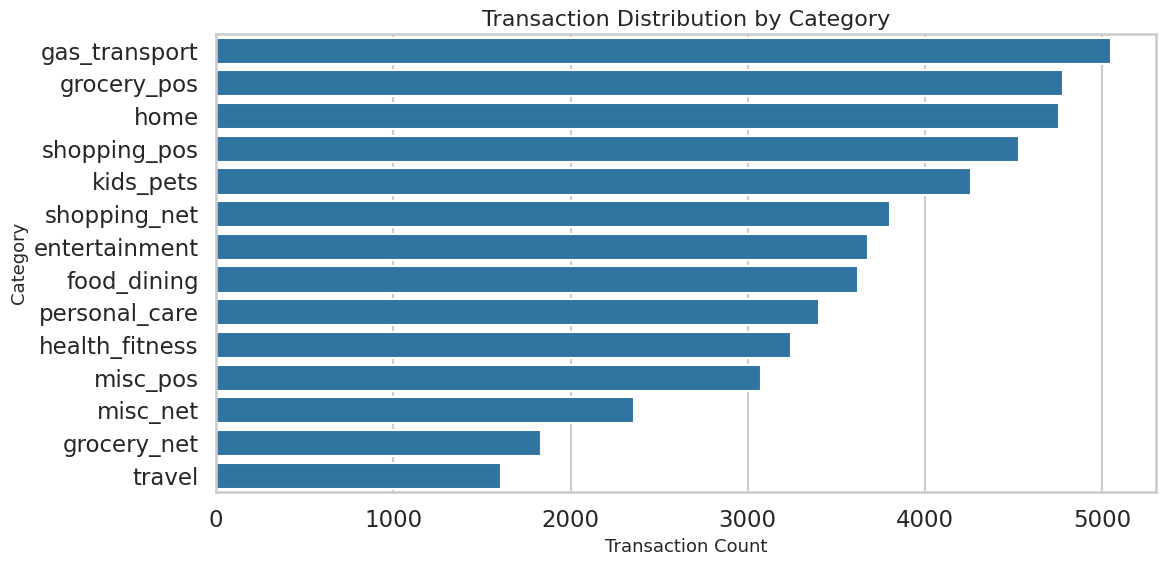

In [ ]:
# Category Distribution
plt.figure(figsize=(12,6))
sns.countplot(y='category',
              data=df_sample,
              order=df_sample['category'].value_counts().index)
plt.title("Transaction Distribution by Category", fontsize=16)
plt.xlabel("Transaction Count", fontsize=13)
plt.ylabel("Category", fontsize=13)
plt.tight_layout()
plt.show()
print("\n")

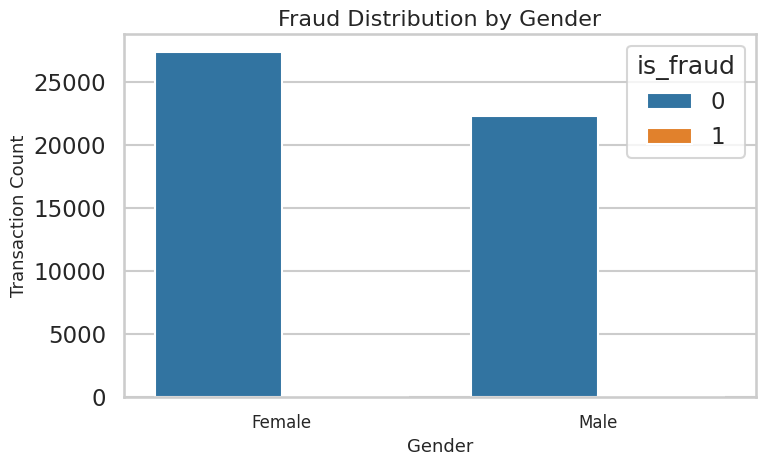

In [ ]:
#Gender vs Fraud
plt.figure(figsize=(8,5))
sns.countplot(x='gender',
              hue='is_fraud',
              data=df_sample)
plt.title("Fraud Distribution by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Transaction Count", fontsize=13)
plt.xticks(ticks=[0,1], labels=['Female','Male'], fontsize=12)
plt.tight_layout()
plt.show()
print("\n")

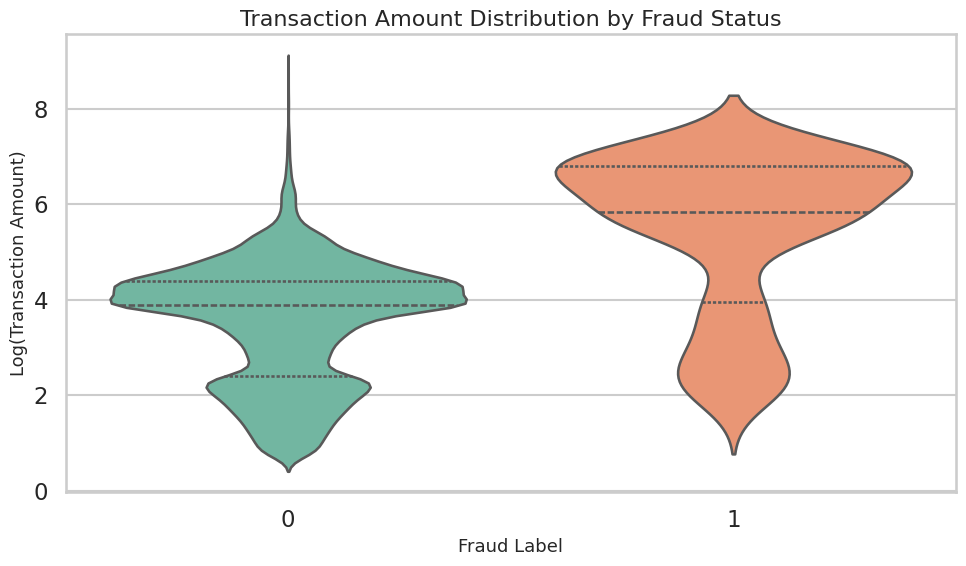

In [ ]:
# Violin Plot – Fraud vs Amount
plt.figure(figsize=(10,6))
sns.violinplot(x='is_fraud',
               y=np.log1p(df_sample['amt']),
               data=df_sample,
               palette="Set2",
               inner="quartile")
plt.title("Transaction Amount Distribution by Fraud Status", fontsize=16)
plt.xlabel("Fraud Label", fontsize=13)
plt.ylabel("Log(Transaction Amount)", fontsize=13)
plt.tight_layout()
plt.show()
print("\n")

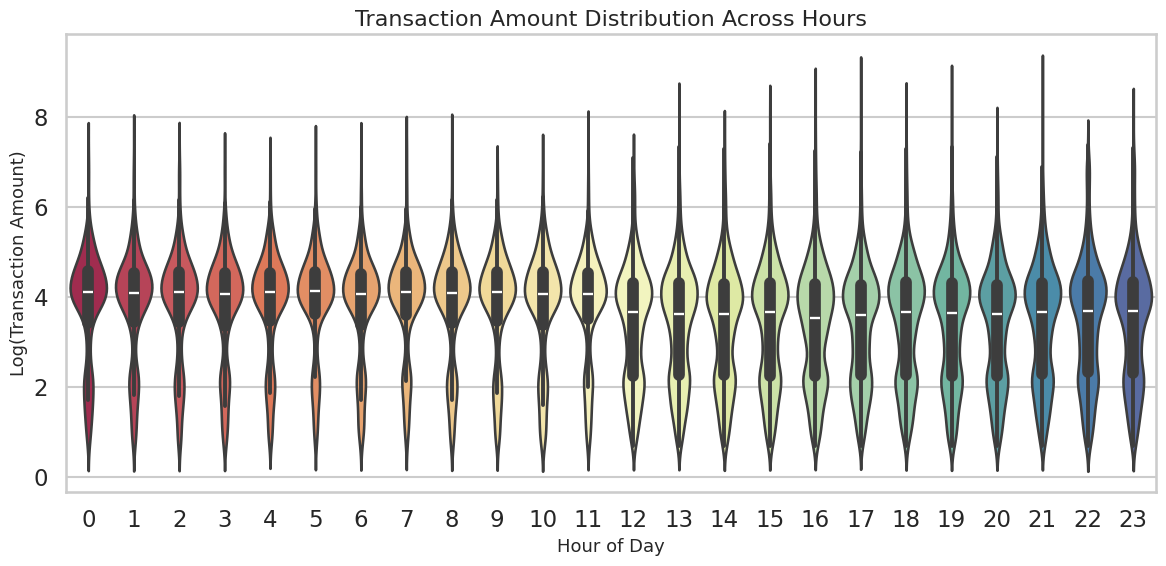

In [ ]:
# Violin Plot – Amount by Hour
plt.figure(figsize=(12,6))
sns.violinplot(x='hour',
               y=np.log1p(df_sample['amt']),
               data=df_sample,
               palette="Spectral")
plt.title("Transaction Amount Distribution Across Hours", fontsize=16)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Log(Transaction Amount)", fontsize=13)
plt.tight_layout()
plt.show()
print("\n")

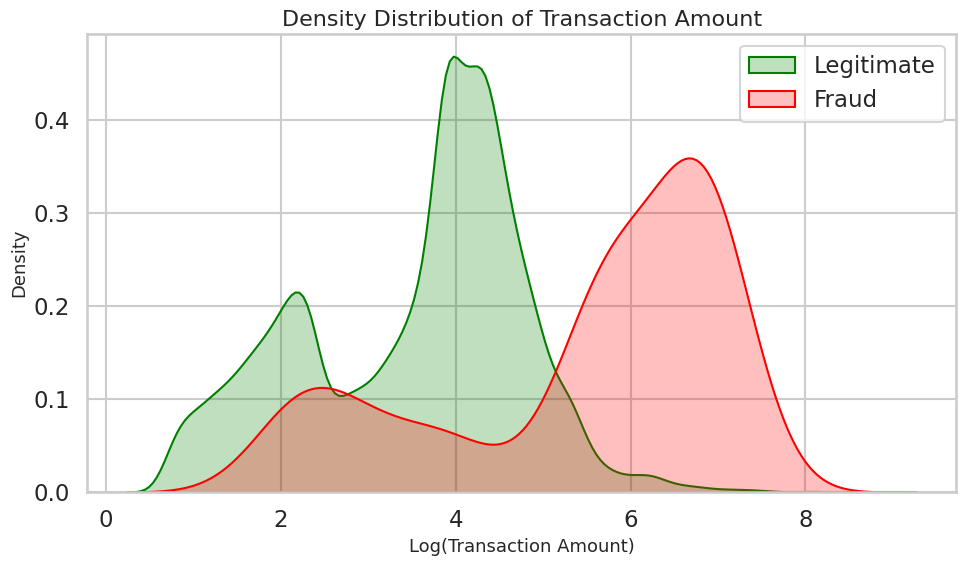

In [ ]:
# KDE Density Plot
plt.figure(figsize=(10,6))
sns.kdeplot(np.log1p(df_sample[df_sample['is_fraud']==0]['amt']),
            label="Legitimate",
            fill=True,
            color="green")
sns.kdeplot(np.log1p(df_sample[df_sample['is_fraud']==1]['amt']),
            label="Fraud",
            fill=True,
            color="red")
plt.title("Density Distribution of Transaction Amount", fontsize=16)
plt.xlabel("Log(Transaction Amount)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
print("\n")

**Time-Based Visualization (Candlestick Chart):**

This section visualizes transaction amount movement over time using a candlestick chart for a specific time period.

In [ ]:
# Candlestick Visualization (Only 2 Months)
df_candle = df_sample.copy()
df_candle['trans_date_trans_time'] = pd.to_datetime(df_candle['trans_date_trans_time'])
df_candle = df_candle[
    (df_candle['trans_date_trans_time'] >= '2019-01-01') &
    (df_candle['trans_date_trans_time'] <= '2019-02-28')
]
df_candle.set_index('trans_date_trans_time', inplace=True)
ohlc = df_candle['amt'].resample('1H').agg(['first','max','min','last']).dropna()
ohlc.columns = ['open','high','low','close']
fig = go.Figure(data=[go.Candlestick(
        x=ohlc.index,
        open=ohlc['open'],
        high=ohlc['high'],
        low=ohlc['low'],
        close=ohlc['close'],
        increasing_line_color='green',
        decreasing_line_color='red'
)])

fig.update_layout(
    title="Transaction Amount Movement Over Time (Jan–Feb 2019)",
    xaxis_title="Transaction Time",
    yaxis_title="Transaction Amount",
    template="plotly_dark"
)

fig.show()

**WEEK 4 - EDA DEEP DIVE**

  In this stage, exploratory data analysis was performed to understand the distribution of transaction amounts, transaction frequency, and fraud patterns.

The histogram of the log-transformed transaction amount shows that most transactions fall within a moderate range, while very high transaction amounts are relatively rare. The boxplot also highlights the presence of some extreme values, indicating potential outliers in transaction amounts.

The analysis of transaction frequency by hour of the day shows that transactions occur throughout the day, with slightly higher activity during the afternoon and evening hours. This suggests that transaction behavior varies based on time.

The comparison between fraudulent and legitimate transactions indicates that fraudulent transactions tend to occur at slightly higher transaction amounts compared to normal transactions. The scatter plot between transaction amount and hour of the day shows that fraud cases appear across multiple hours but are relatively sparse.

Additionally, the fraud distribution plot confirms that fraudulent transactions are extremely rare compared to legitimate ones, highlighting the class imbalance in the dataset. The fraud rate by hour analysis shows that certain hours have slightly higher fraud rates, suggesting that time-based patterns may help in fraud detection.

**WEEK 06 – FEATURE ENGINEERING:**

This stage focuses on transforming the dataset into a more suitable format for analysis by improving feature quality. Feature engineering involves handling skewness, encoding categorical variables, and applying scaling techniques. These steps enhance data consistency, improve interpretability, and make the dataset more effective for visualization and further analysis.

**Identifying Numerical Columns:**

This step extracts numerical columns from the dataset and excludes the target variable to ensure that transformations are applied only to relevant features.

In [ ]:
print("Week - 06")
#Feature Engineering

sns.set_style("whitegrid")
# Identify Numerical Columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Remove target column from transformation
if 'is_fraud' in numeric_cols:
    numeric_cols = numeric_cols.drop('is_fraud')
print("\nNumerical Columns used for Feature Engineering:")
print(numeric_cols)

Week - 06

Numerical Columns used for Feature Engineering:
Index(['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'amt_scaled', 'hour'],
      dtype='object')


**Detecting Skewness:**

Skewness is calculated to identify features that are not normally distributed and may affect analysis.

In [ ]:
# Detect Skewness in Numerical Features
print("\nChecking Skewness of Numerical Features")
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))
print("\nSkewness Before Transformation:")
print(skew_values.sort_values(ascending=False))


Checking Skewness of Numerical Features

Skewness Before Transformation:
amt           42.334251
amt_scaled    42.334251
city_pop       5.597503
cc_num         2.851876
zip            0.079681
unix_time      0.003378
merch_lat     -0.181915
lat           -0.186027
hour          -0.282825
merch_long    -1.146959
long          -1.150106
dtype: float64


**Fixing Skewness using Log Transformation:**

Log transformation is applied to reduce skewness and make distributions more symmetric.


Applying Log Transformation for Highly Skewed Features


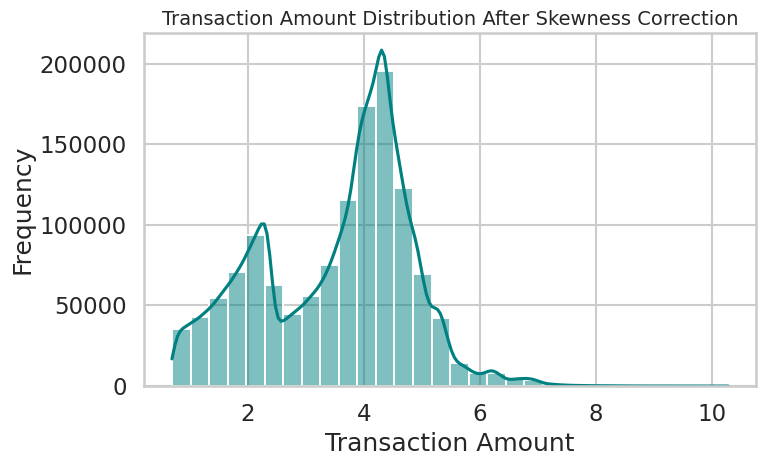

In [ ]:
# Fix Skewness using Log Transformation
print("\nApplying Log Transformation for Highly Skewed Features")
for col in numeric_cols:
    if abs(skew(df[col].dropna())) > 1:
        if (df[col] <= 0).any():
            df[col] = df[col] - df[col].min() + 1
        df[col] = np.log1p(df[col])

# Visualization : Distribution After Skewness Correction
if 'amt' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['amt'], bins=30, kde=True, color="teal")
    plt.title("Transaction Amount Distribution After Skewness Correction", fontsize=14)
    plt.xlabel("Transaction Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Encoding Categorical Variables:**

Categorical features are converted into numerical format using label encoding.

In [ ]:
# Encode Categorical Variables
print("\nEncoding Categorical Variables")
cat_cols = df.select_dtypes(include=['object','category']).columns
label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


Encoding Categorical Variables


**Applying Standard Scaling:**

Standard scaling transforms features to have a mean of 0 and standard deviation of 1.


Applying Standard Scaling

Sample Standard Scaled Data:
     cc_num       amt       zip       lat      long  city_pop  unix_time  \
0  0.257715 -1.356008 -0.749136 -0.484420  0.542295 -0.082289  -1.858664   
1 -1.882392  0.892683  1.872567  2.039120 -1.741927 -1.367366  -1.858662   
2 -0.827809  1.447113  1.281042  0.717754 -1.277769 -0.011809  -1.858662   
3  0.326299  0.228658  0.402753  1.515617 -1.266852 -0.322646  -1.858660   
4 -0.247360  0.175597 -0.906090 -0.023035  0.622551 -1.532846  -1.858651   

   merch_lat  merch_long  amt_scaled      hour  
0  -0.494354    0.511873   -0.925790 -1.878145  
1   2.078699   -1.784186    0.723404 -1.878145  
2   0.902849   -1.304191    1.898349 -1.878145  
3   1.662886   -1.334897   -0.175737 -1.878145  
4   0.026941    0.676354   -0.226897 -1.878145  


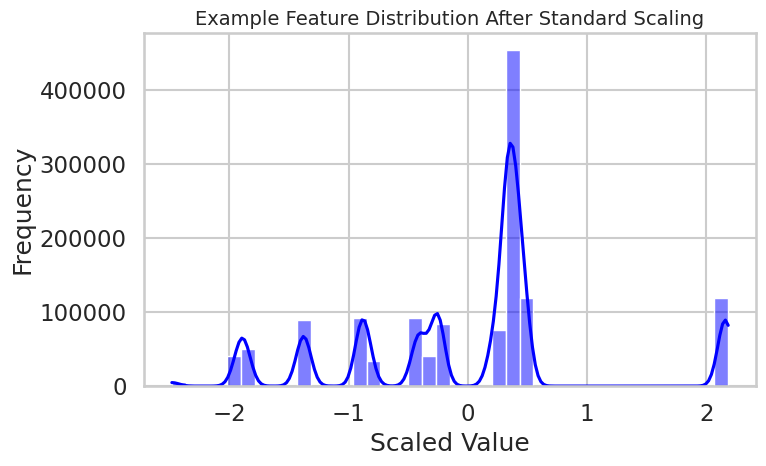

In [ ]:
# Apply Standard Scaling
print("\nApplying Standard Scaling")
standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])
print("\nSample Standard Scaled Data:")
print(df_standard_scaled[numeric_cols].head())

# Visualization : Example Feature After Standard Scaling
plt.figure(figsize=(8,5))
sns.histplot(df_standard_scaled[numeric_cols[0]], bins=40, kde=True, color="blue")
plt.title("Example Feature Distribution After Standard Scaling",fontsize=14)
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Applying Min-Max Normalization:**

Min-Max scaling transforms values into a fixed range between 0 and 1.


Applying Min-Max Normalization

Sample Normalized Data:
     cc_num       amt       zip       lat      long  city_pop     unix_time  \
0  0.587424  0.114152  0.278069  0.343968  0.963597  0.425591  0.000000e+00   
1  0.128642  0.416601  0.993677  0.618450  0.820634  0.156571  5.598526e-07   
2  0.354716  0.491172  0.832217  0.474727  0.849684  0.440346  7.105821e-07   
3  0.602126  0.327290  0.592483  0.561509  0.850367  0.375274  1.248902e-06   
4  0.479149  0.320153  0.235227  0.394153  0.968620  0.121929  3.617509e-06   

   merch_lat  merch_long  amt_scaled  hour  
0   0.350302    0.959109    0.005046   0.0  
1   0.621488    0.821700    0.102941   0.0  
2   0.497559    0.850426    0.172685   0.0  
3   0.577663    0.848588    0.049568   0.0  
4   0.405244    0.968953    0.046532   0.0  


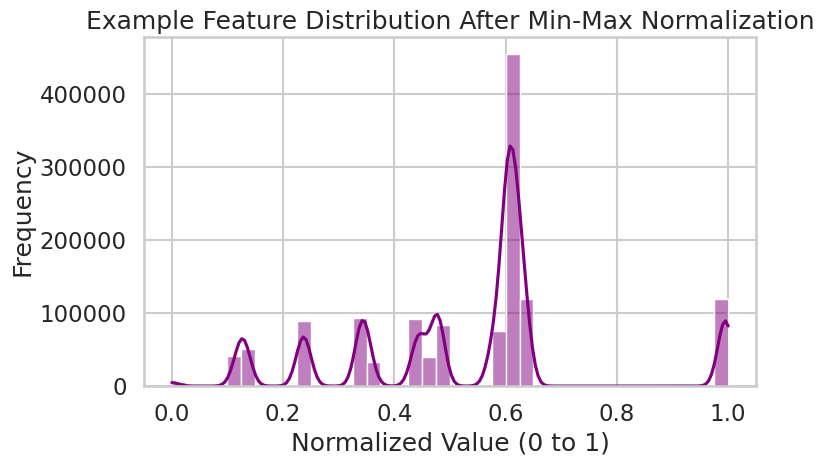

In [ ]:
# Apply Min-Max Normalization
print("\nApplying Min-Max Normalization")
minmax_scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])
print("\nSample Normalized Data:")
print(df_normalized[numeric_cols].head())

# Visualization : Example Feature After Min-Max Normalization
plt.figure(figsize=(8,5))
sns.histplot(df_normalized[numeric_cols[0]], bins=40, kde=True, color="purple")
plt.title("Example Feature Distribution After Min-Max Normalization")
plt.xlabel("Normalized Value (0 to 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Comparing Transformations:**

This section compares original, standard scaled, and normalized distributions of a feature.

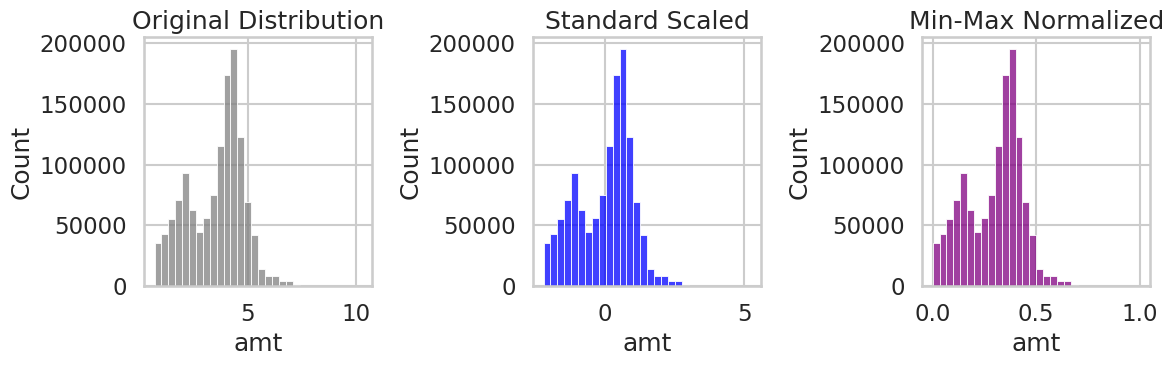

In [ ]:
print("\n\n")
feature = 'amt' if 'amt' in numeric_cols else numeric_cols[0]
plt.figure(figsize=(12,4))

# Original Data
plt.subplot(1,3,1)
sns.histplot(df[feature], bins=30, color="gray")
plt.title("Original Distribution")

# Standard Scaled
plt.subplot(1,3,2)
sns.histplot(df_standard_scaled[feature], bins=30, color="blue")
plt.title("Standard Scaled")

# Normalized
plt.subplot(1,3,3)
sns.histplot(df_normalized[feature], bins=30, color="purple")
plt.title("Min-Max Normalized")

plt.tight_layout()
plt.show()

# Save Feature Engineered Dataset
df_normalized.to_csv("fraud_feature_engineered_dataset.csv", index=False)

**FEATURE ENGINEERING - INTERPRETATION**

First, the numerical columns were identified, excluding the target variable (is_fraud). The skewness of these numerical features was calculated to understand the distribution of the data. Some features showed high skewness, indicating that the data distribution was not balanced.

To address this, log transformation was applied to highly skewed features. This transformation reduces the impact of extreme values and helps in making the distribution more stable and suitable for analysis.

Next, categorical variables such as merchant, category, city, and job were converted into numerical format using Label Encoding. This step ensures that categorical data can be effectively used in analysis and visualization.

After encoding, feature scaling techniques were applied. Standard Scaling was used to standardize numerical features so that they have a mean close to 0 and a standard deviation of 1. In addition, Min-Max Normalization was applied to scale the features within a range of 0 to 1, making comparisons between features easier.

Finally, the distributions of features after transformation and scaling were visualized to verify that the data had been properly processed. The feature-engineered dataset was then saved for further analysis and visualization tasks.

Overall, this step improved the dataset by reducing skewness, converting categorical data into numerical form, and scaling the features, making it more consistent and suitable for extracting meaningful insights.

**WEEK 07 – DIMENSIONALITY REDUCTION:**

Reducing the number of features while preserving the important information in the dataset. Dimensionality reduction helps in simplifying the dataset, improving visualization, and identifying the most relevant features. It also makes patterns in the data easier to interpret. Techniques such as feature selection and Principal Component Analysis (PCA) are used in this stage.

In [ ]:
print("WEEK -07")
#Dimensionality Reduction
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

WEEK -07


**Data Preparation:**

The dataset is cleaned by removing unnecessary columns and extracting useful features from the date column. Time-based features such as hour, day, and month are created to capture temporal patterns in transactions. The original timestamp column is then removed to avoid redundancy. This step ensures that the dataset contains only relevant and meaningful features for analysis.

In [ ]:

# Data Preparation
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
if 'trans_date_trans_time' in df.columns:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df.drop(columns=['trans_date_trans_time'], inplace=True)
else:
    print("Column already removed")

**Balanced Sampling:**

A balanced sample is created to reduce the imbalance between fraud and non-fraud transactions. Fraud cases are kept as they are, while a controlled number of non-fraud cases are selected. This helps in better comparison and visualization of patterns. Balanced data improves the clarity of insights when analyzing relationships between features.

In [ ]:
# Balanced Sampling
fraud = df[df['is_fraud'] == 1]
non_fraud = df[df['is_fraud'] == 0].sample(len(fraud)*5, random_state=42)
df_sample = pd.concat([fraud, non_fraud])
print("Sample Shape:", df_sample.shape)

Sample Shape: (45036, 25)


**Extracting Numerical Features:**

Only numerical features are selected for dimensionality reduction, as PCA works on numerical data. The target variable is separated from the feature set. This step ensures that transformations are applied only to input features. It also prepares the dataset for feature selection and scaling.

In [ ]:
#Numerical Features
numeric_df = df_sample.select_dtypes(include=np.number)
X = numeric_df.drop(columns=['is_fraud'])
y = numeric_df['is_fraud']

**Feature Selection:**

SelectKBest is used to identify the most important features based on statistical significance. The top features are selected using the ANOVA F-test method. This reduces the dimensionality by keeping only the most relevant features. It also improves interpretability by focusing on features that contribute the most information.

In [ ]:
# Feature Selection
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("\nSelected Features:", selected_features)
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)


Selected Features: Index(['category', 'amt', 'gender', 'dob', 'unix_time', 'amt_scaled', 'hour',
       'month'],
      dtype='object')


**Feature Scaling:**

Standard scaling is applied to normalize the selected features. This ensures that all features contribute equally to PCA without being influenced by their original scale. Scaling is important because PCA is sensitive to feature magnitude. It helps in improving the quality of dimensionality reduction.

In [ ]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected_df)

**Applying PCA and Visualizing:**

Principal Component Analysis (PCA) is applied to reduce the dataset into two components for visualization. These components capture the maximum variance in the data. PCA transforms the original features into a new set of uncorrelated variables. This makes it easier to visualize complex high-dimensional data.

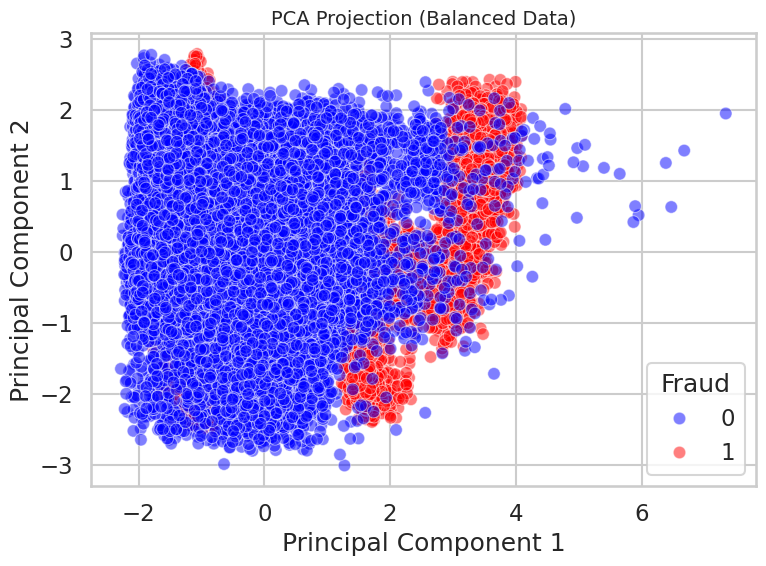

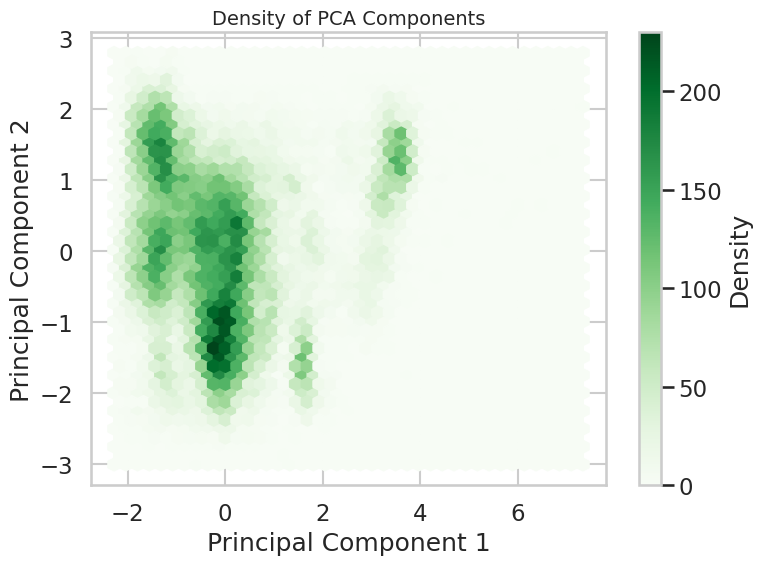

In [ ]:
# PCA (2 Components for Visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#PCA Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y,
                palette={0: "blue", 1: "red"}, alpha=0.5)

plt.title("PCA Projection (Balanced Data)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Fraud")
plt.tight_layout()
plt.show()

# PCA Density Plot
plt.figure(figsize=(8,6))
plt.hexbin(X_pca[:,0], X_pca[:,1], gridsize=40, cmap='Greens')
plt.title("Density of PCA Components", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Density")
plt.tight_layout()
plt.show()

**Explained Variance (Line Plot):**

This plot shows how much variance is explained as more components are added. It helps in understanding how many components are needed to represent the data effectively. A higher cumulative variance indicates better information retention. This is useful for deciding the optimal number of components.

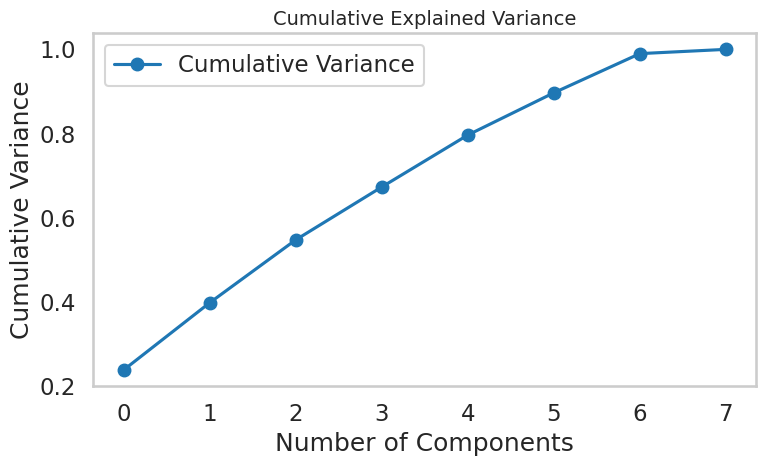

In [ ]:
#Explained Variance (Line Plot)
pca_full = PCA()
pca_full.fit(X_scaled)
variance = pca_full.explained_variance_ratio_
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(variance), marker='o', label="Cumulative Variance")
plt.title("Cumulative Explained Variance", fontsize=14)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

**Feature Importance Plot:**

This plot shows the importance of each feature selected using SelectKBest. Features with higher scores contribute more to distinguishing patterns in the data. It helps in understanding which features are most relevant. This improves interpretability of the dataset.

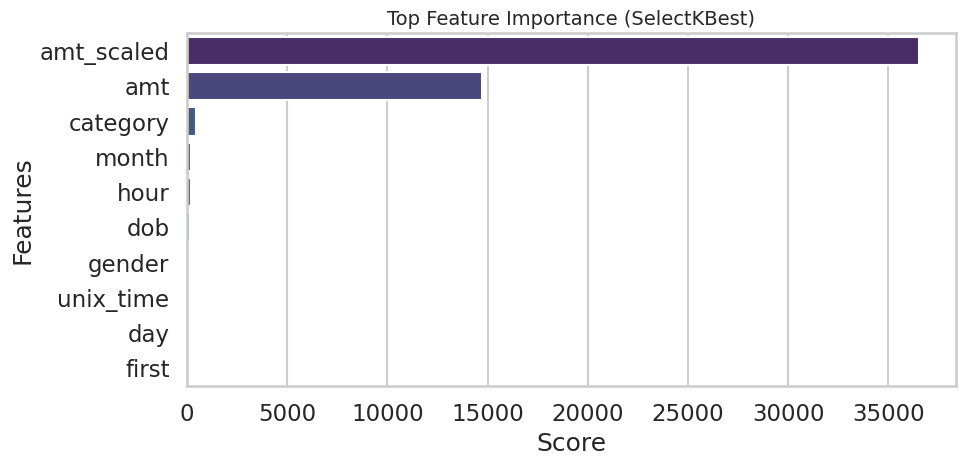

In [ ]:
#Feature Importance Plot
scores = selector.scores_
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(10), palette='viridis')
plt.title("Top Feature Importance (SelectKBest)", fontsize=14)
plt.xlabel("Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

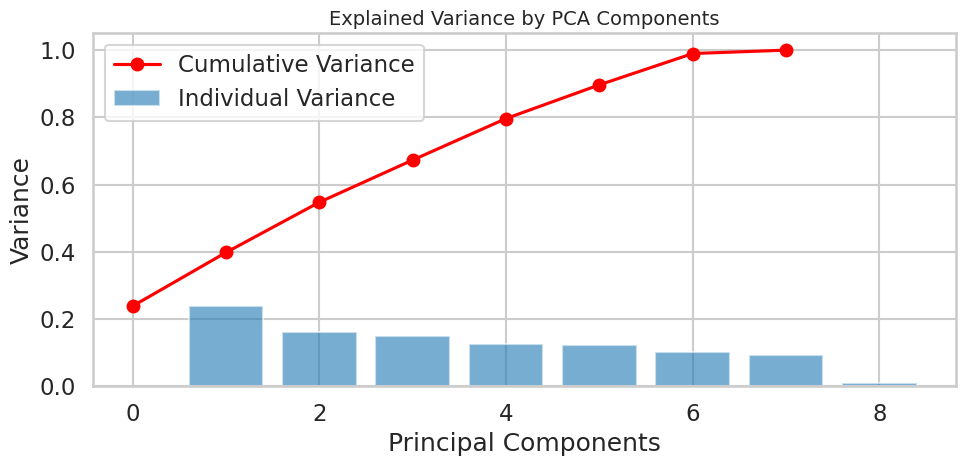

In [ ]:
#Explained Variance (Bar + Line)
plt.figure(figsize=(10,5))
plt.bar(range(1, len(variance)+1), variance, alpha=0.6, label='Individual Variance')
plt.plot(np.cumsum(variance), marker='o', color='red', label='Cumulative Variance')
plt.title("Explained Variance by PCA Components", fontsize=14)
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.show()

**PCA Loadings Heatmap:**

The heatmap shows how each feature contributes to the principal components. It helps in understanding the relationship between original features and reduced components. Strong positive or negative values indicate higher influence. This aids in interpreting the meaning of principal components.

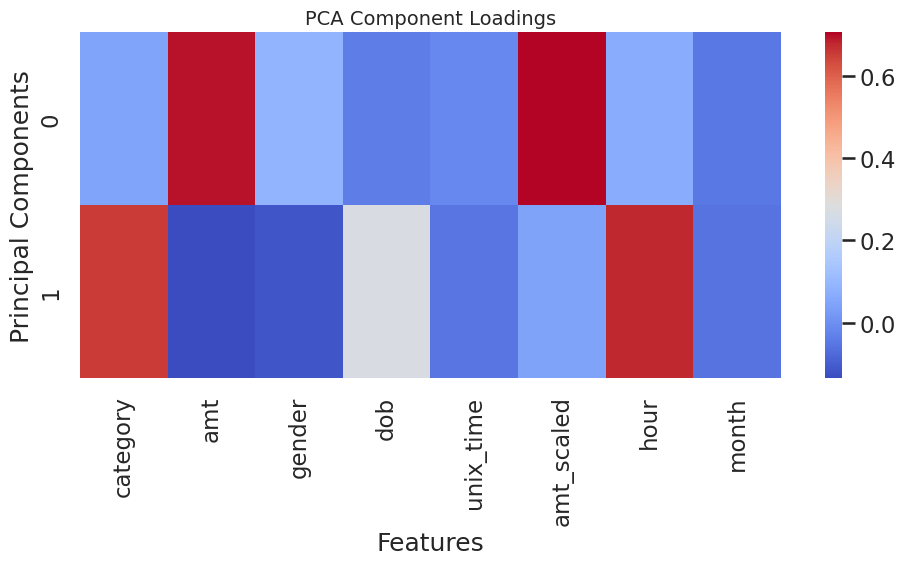

In [ ]:
#PCA Loadings Heatmap
loadings = pd.DataFrame(pca.components_, columns=selected_features)
plt.figure(figsize=(10,6))
sns.heatmap(loadings, cmap='coolwarm')
plt.title("PCA Component Loadings", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Principal Components")
plt.tight_layout()
plt.show()

**PCA with Optimal Component Selection (90% Variance):**

In this section, PCA is applied in a more practical way by retaining 90% of the total variance instead of fixing the number of components. This approach ensures that most of the important information in the dataset is preserved while still reducing dimensionality. It helps in finding a balance between reducing complexity and maintaining data quality. The number of components required is automatically determined based on the variance threshold.

In [ ]:
# PCA for Better Representation (90% Variance)
print("\nApplying PCA to retain 90% variance")

pca_optimal = PCA(n_components=0.90)  # retain 90% variance
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print("Number of Components Selected:", pca_optimal.n_components_)
print("Explained Variance:", np.sum(pca_optimal.explained_variance_ratio_))


Applying PCA to retain 90% variance
Number of Components Selected: 7
Explained Variance: 0.9898858676151947


**Scree Plot:**

A scree plot is used to visualize how much variance is captured as the number of components increases. The red dashed line represents the 90% threshold, making it easy to identify the point where most of the information is retained. This plot is useful for understanding how quickly variance accumulates and where it starts to level off. It provides a visual confirmation of the optimal number of components.

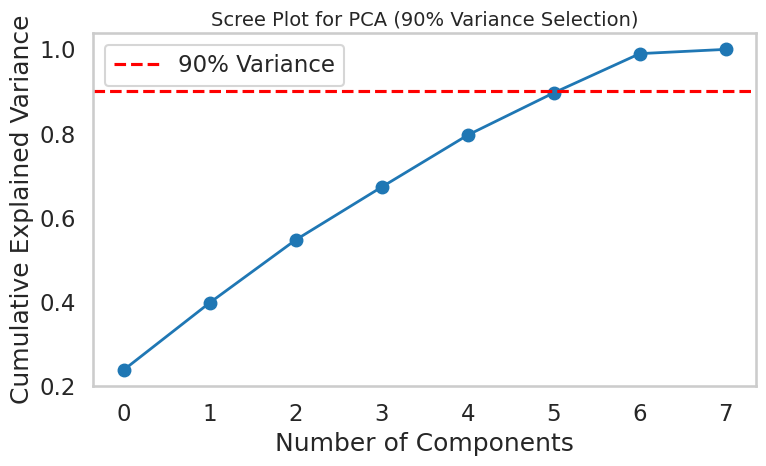

In [ ]:
# Scree Plot
plt.figure(figsize=(8,5))
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(cum_var, marker='o', linewidth=2)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance')
plt.title("Scree Plot for PCA (90% Variance Selection)", fontsize=14)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

**Comparing PCA Approaches:**

A simple comparison is made between using only 2 components and using enough components to retain 90% variance. This highlights the trade-off between simplicity and information retention. While 2 components are useful for visualization, retaining 90% variance preserves much more information from the original dataset. This comparison makes it easier to understand which approach is more suitable depending on the purpose.

In [ ]:
# Compare PCA 2 vs PCA 90%
comparison = pd.DataFrame({
    "Method": ["PCA (2 Components)", "PCA (90% Variance)"],
    "Components Used": [2, pca_optimal.n_components_],
    "Variance Retained": [
        np.sum(pca.explained_variance_ratio_),
        np.sum(pca_optimal.explained_variance_ratio_)
    ]
})
print("\nPCA Comparison:\n")
print(comparison)


PCA Comparison:

               Method  Components Used  Variance Retained
0  PCA (2 Components)                2           0.397702
1  PCA (90% Variance)                7           0.989886


**Pairplot Visualization:**

A pairplot is created for a smaller sample to visualize relationships between selected features. It shows pairwise relationships and distributions in a compact form. Different colors represent fraud and non-fraud classes. This helps in identifying patterns and correlations between features.

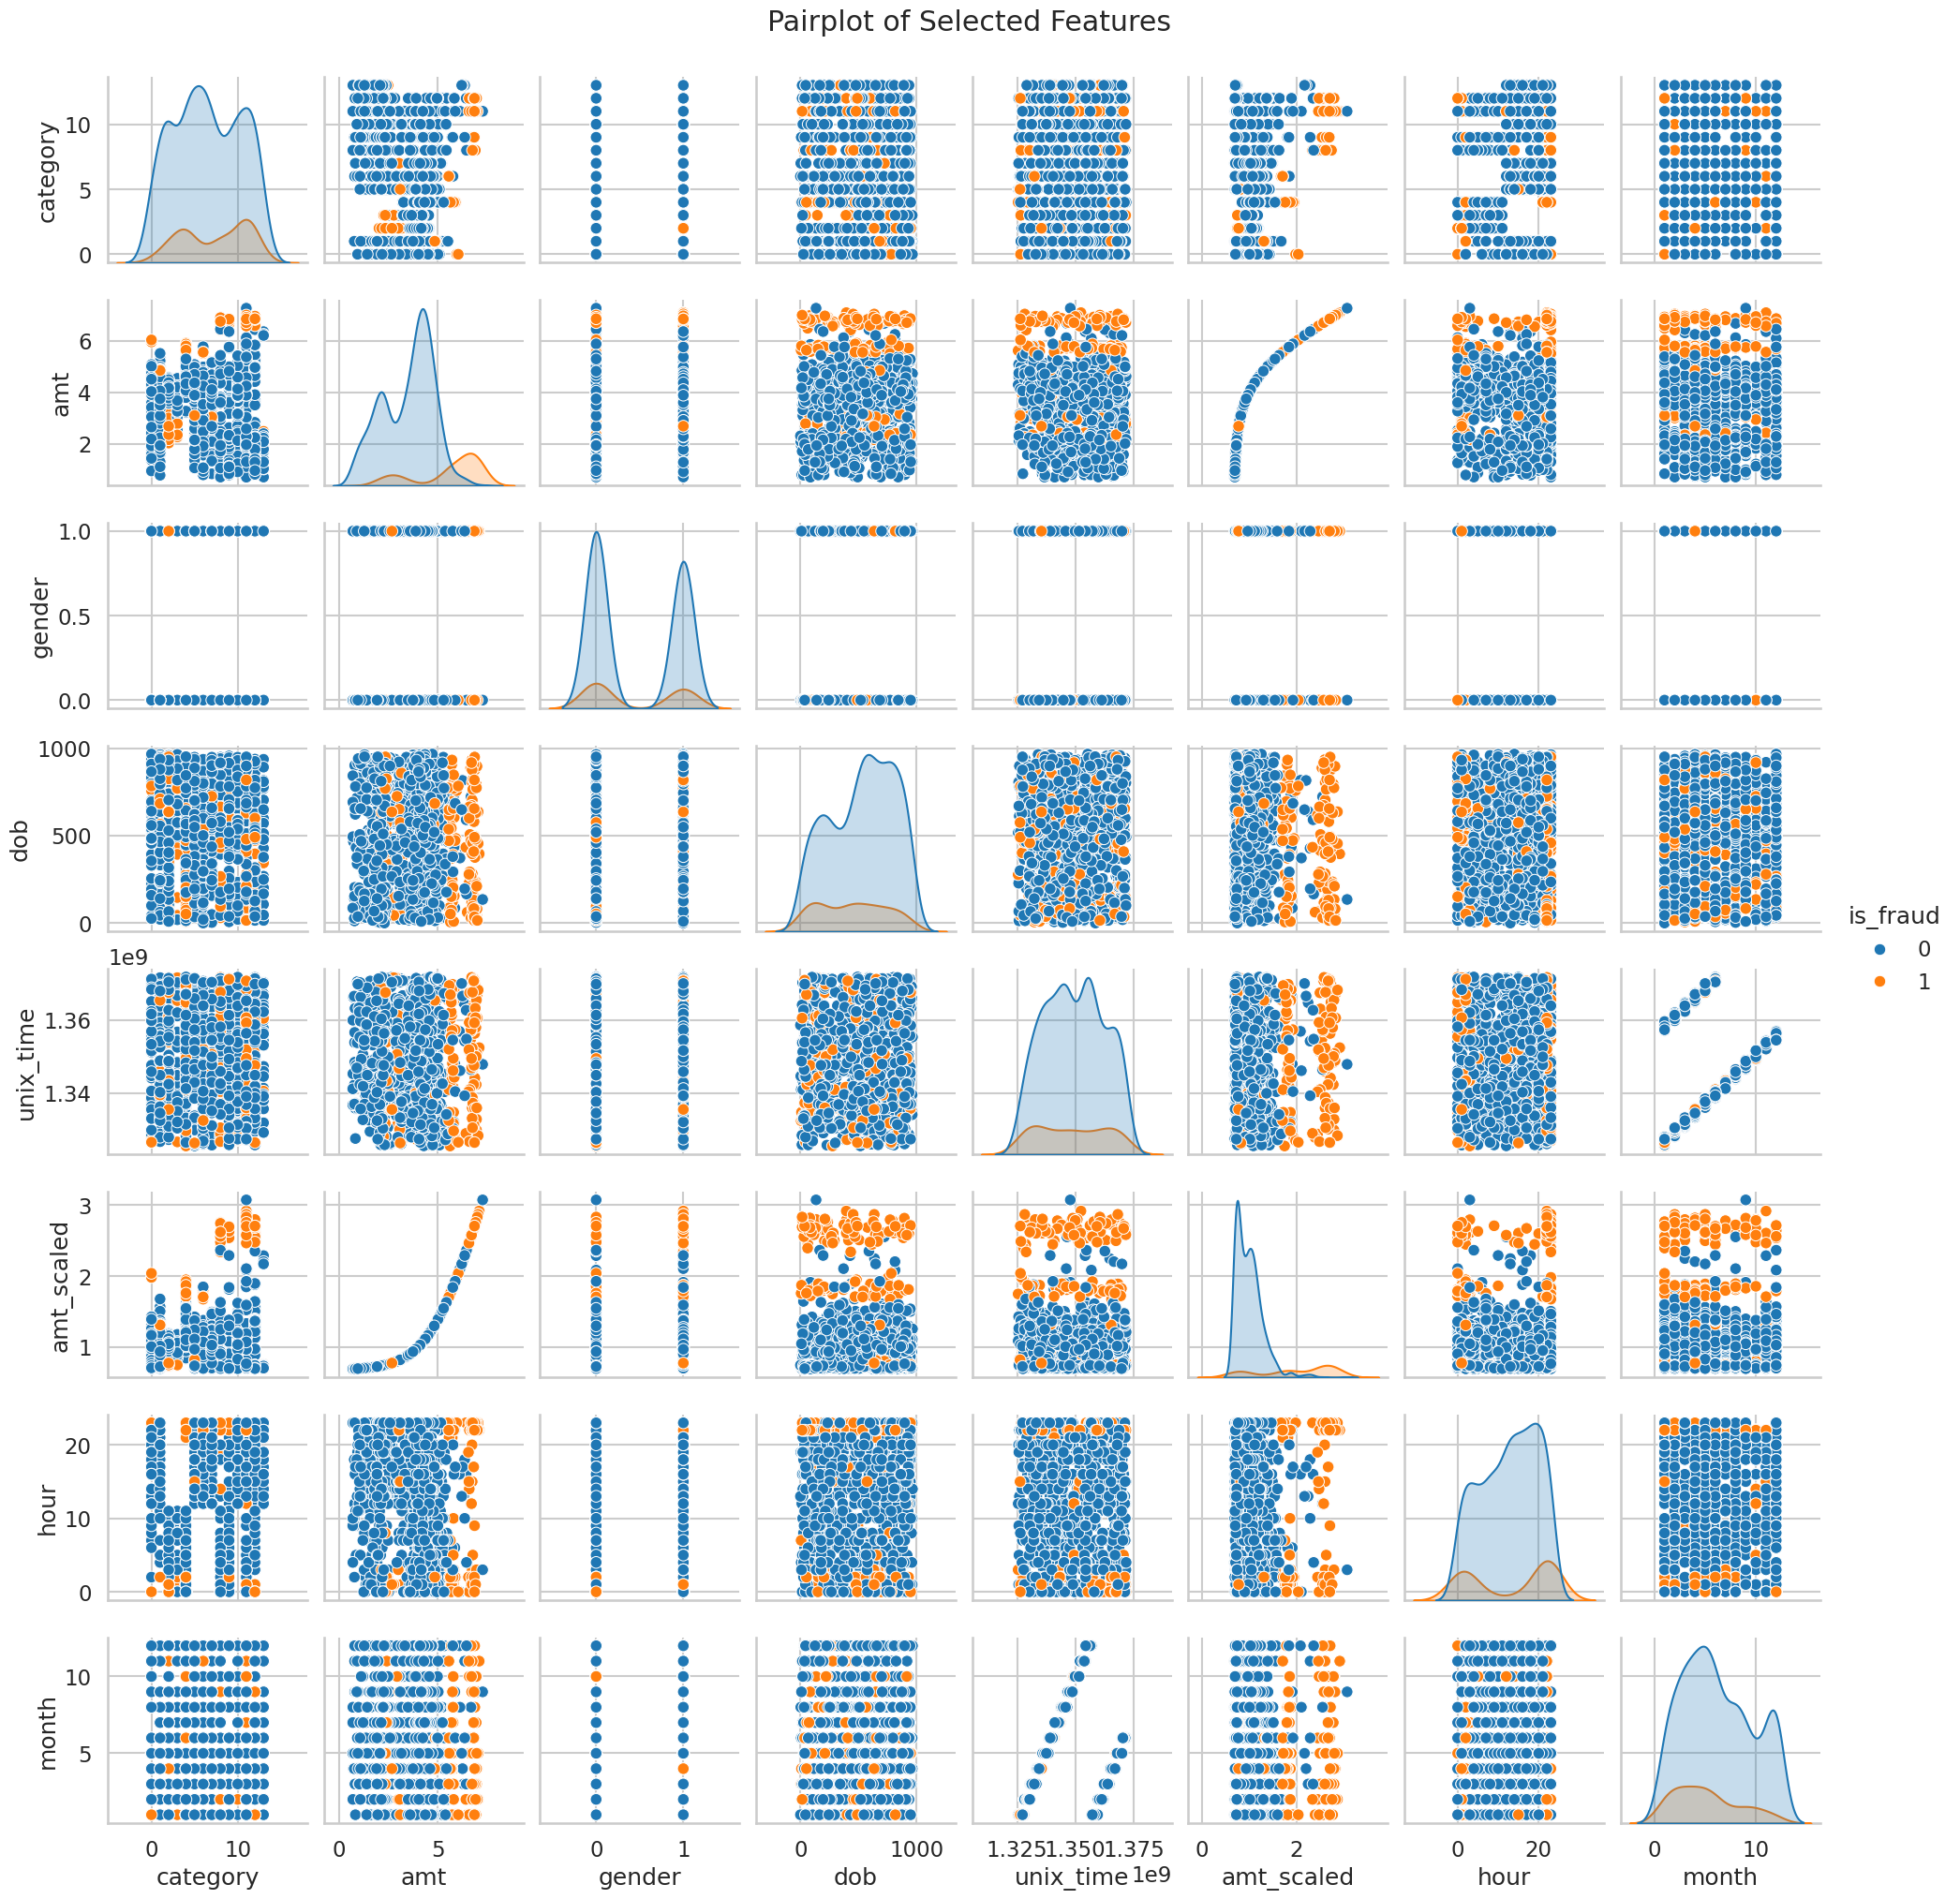

In [ ]:
#Pairplot (Small Sample)
sample_small = X_selected_df.sample(1000, random_state=42)
sample_small['is_fraud'] = y.sample(1000, random_state=42).values
sns.pairplot(sample_small, hue='is_fraud', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

**DIMENSIONALITY REDUCTION – INTERPRETATION:**

First, the dataset was prepared by removing unnecessary columns and extracting useful time-based features such as hour, day, and month from the transaction timestamp. This helped in capturing important temporal patterns in the data. A balanced sample was then created by selecting all fraud cases and a proportion of non-fraud cases, making the dataset more suitable for comparison and analysis.

Next, only numerical features were selected for dimensionality reduction, and the target variable (is_fraud) was separated. Feature selection was performed using the SelectKBest method, which identified the most important features based on statistical significance. This reduced the number of features while retaining the most relevant information.

After selecting the important features, standard scaling was applied to ensure that all features were on a similar scale. This step is important because dimensionality reduction techniques like PCA are sensitive to differences in feature magnitude.

Principal Component Analysis (PCA) was then applied to transform the selected features into a smaller set of components. These components capture the maximum variance in the data, allowing the dataset to be represented in fewer dimensions while preserving important patterns.

Various visualizations such as scatter plots, density plots, and explained variance graphs were used to analyze the transformed data. These plots helped in understanding how well the data is distributed in reduced dimensions and how much information is retained by the principal components.